In [2]:
import numpy as np
from helpers import *
import matplotlib.pyplot as plt
import tqdm

2025-12-04 09:43:07.920 | INFO     | time_series.config:<module>:13 - PROJ_ROOT path is: /home/james/Repo/PhD Repo/time_series_clustering
/home/james/Repo/PhD Repo/time_series_clustering/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from sklearn.model_selection import KFold

In [4]:
class ModifiedGaussianKernel:
    def __init__(self, bandwidth):
        self.bandwidth = bandwidth
        
    def __call__(self, x1, x2):
        x1_dim = len(x1.shape)
        x2_dim = len(x2.shape)

        if x1_dim != x2_dim:
            raise Exception("GaussianKernel: x1 and x2 should have the same number of dimensions")

        if x1_dim == 1:
            return np.exp(-(x2[np.newaxis, :]- x1[:, np.newaxis])**2/(2*self.bandwidth**2))*(1/self.bandwidth)
        elif x1_dim == 2:
            return np.exp(-np.linalg.norm(x2[np.newaxis, :, :]- x1[:, np.newaxis, :], axis=2)**2/(2*self.bandwidth**2))*(1/self.bandwidth)
        else:
            return np.exp(-np.linalg.norm(x2[np.newaxis, :, :]- x1[:, np.newaxis, :], axis=(2, 3))**2/(2*self.bandwidth**2))*(1/self.bandwidth)

        raise Exception("Number of dimensions of the data is too big!")


In [5]:
def mean_squared_error_cv(x, y, model, nfolds=5):
    kf = KFold(n_splits=nfolds, random_state=None, shuffle=False)
    scores = []
    
    for i, (train_index, test_index) in enumerate(kf.split(x)):
        X_train = x[train_index]
        X_test = x[test_index]

        y_train = y[train_index]
        y_test = y[test_index] 

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        score = mean_squared_error(y_test, y_pred)
        scores.append(score)
    return np.mean(scores)

In [6]:
class ModifiedKRRWrapper(BaseEstimator):
    def __init__(self, bandwidth, reg):
        self.model = KernelRidgeRegression(
            kernels=[ModifiedGaussianKernel(bandwidth=bandwidth)],
            reg = reg
        )

    def fit(self, X, y):
        self.model.fit(X, y)

    def predict(self, X):
        return self.model.predict(X)

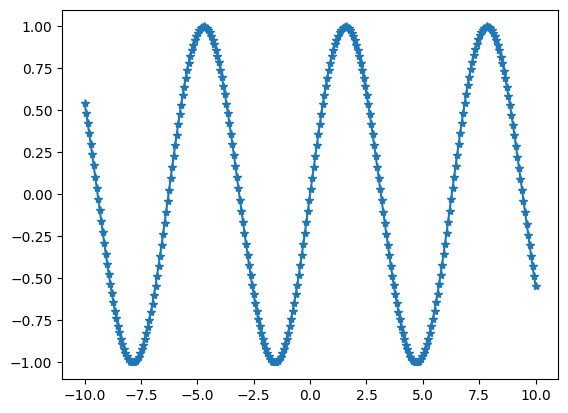

In [9]:
f = lambda x: np.sin(x)

x = np.linspace(-10, 10, 300)
y = f(x)

plt.plot(x, y, "-*")

In [7]:
paramsearch = GridSearch(
    ModifiedKRRWrapper,
    param_grid=dict(
        bandwidth=np.linspace(1, 5, 50),
        reg = np.linspace(1e-9, 1e-2, 20)
    )
)

In [8]:
# DS 1
y1 = f(x) + np.random.normal(0, 1, len(x))

paramsearch.fit(x, y1)

b1, r1 = paramsearch.best_params.values()

model1 = ModifiedKRRWrapper(b1, r1)
mean_squared_error_cv(x, y, model1)

np.float64(0.4887273713071517)

In [ ]:
model1.fit(x, y1)

kernel1 = model1.model.kernels[0]
alpha1 = model1.model.alpha

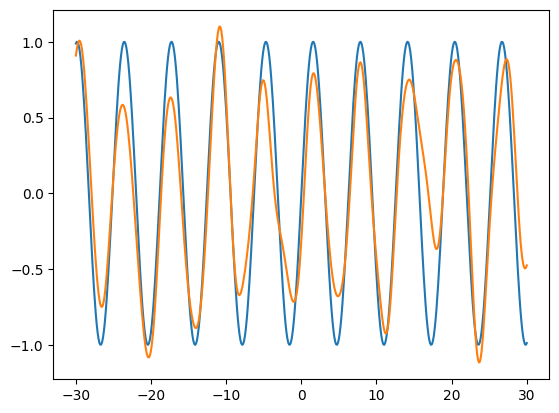

In [10]:
# plt.scatter(x, y1)
plt.plot(x, f(x))
plt.plot(x, model1.predict(x))

In [13]:
# DS 2
l = 1.5
y2 = f(l*x) + np.random.normal(0, 1, len(x))

paramsearch.fit(x, y2)

b2, r2 = paramsearch.best_params.values()

model2 = ModifiedKRRWrapper(b2, r2)
mean_squared_error_cv(x, y, model2)

np.float64(0.48651006703604677)

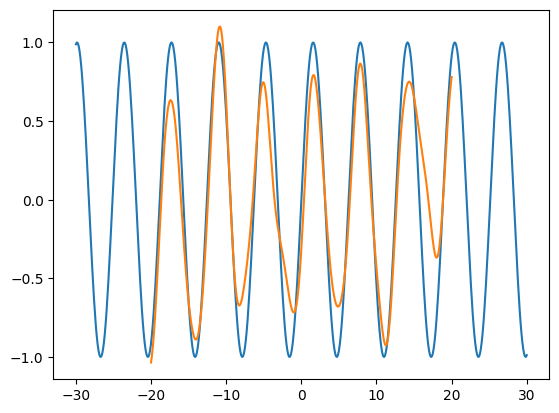

In [14]:
plt.plot(x, f(x))
plt.plot(x/l, model1.predict(x/l))

In [15]:
b1, b2

(np.float64(1.0), np.float64(1.0))

In [16]:
model2.fit(x, y2)

kernel2 = model2.model.kernels[0]

alpha2 = model2.model.alpha

In [17]:
ip1 = (alpha1.T@kernel1(x, x)@alpha1)[0][0]
ip1

np.float64(14.51147901491973)

In [18]:
ip2 = (alpha2.T@kernel2(x, x)@alpha2)[0][0]
ip2

np.float64(18.522454582476616)

In [19]:
c = b1/b2

ip12 = (alpha2.T@kernel1(c*x, x)@alpha1)[0,0]*c
ip12

np.float64(0.20635150980250955)

In [20]:
ip12/np.sqrt(ip1*ip2)

np.float64(0.012586429352461096)

In [ ]:
1/0

ZeroDivisionError: division by zero

In [ ]:
paramsearch = GridSearch(
    ModifiedKRRWrapper,
    param_grid=dict(
        bandwidth=np.linspace(0.1, 5, 100),
        reg = np.linspace(1e-9, 1e-2, 20)
    )
)

In [ ]:
res = []

for i in tqdm.tqdm(range(10)):
    # DS 1
    y1 = f(x) + np.random.normal(0, 1, len(x))

    paramsearch.fit(x, y1)

    b1, r1 = paramsearch.best_params.values()

    model1 = ModifiedKRRWrapper(b1, r1)
    model1.fit(x, y1)


    alpha1 = model1.model.alpha
    kernel1 = model1.model.kernels[0]

    # DS 2
    l = 2
    y2 = f(l*x) + np.random.normal(0, 1, len(x))


    paramsearch.fit(x, y2)

    b2, r2 = paramsearch.best_params.values()

    model2 = ModifiedKRRWrapper(b2, r2)
    model2.fit(x, y2)

    alpha2 = model2.model.alpha
    kernel2 = model2.model.kernels[0]
    # Test

    c = (b1/b2)
    ip1 = (alpha1.T@kernel1(x, x)@alpha1)[0][0]
    ip2 = (alpha2.T@kernel2(x, x)@alpha2)[0][0]
    ip12 = (alpha2.T@kernel1(c*x, x)@alpha1)[0,0]*c

    sim = ip12/np.sqrt(ip1 * ip2)

    res.append(sim)


100%|██████████| 10/10 [01:59<00:00, 11.97s/it]


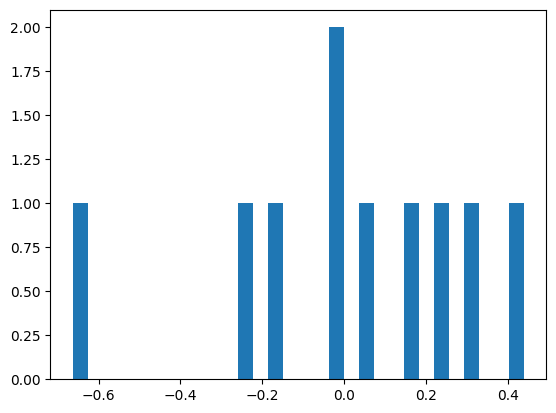

In [ ]:
plt.hist(res, bins=30);

In [ ]:
res

[np.float64(-0.22671621497817399),
 np.float64(-0.6622064119777792),
 np.float64(-0.0027307541628545347),
 np.float64(0.313671890872128),
 np.float64(-0.01261883952994779),
 np.float64(0.4378572949051662),
 np.float64(-0.16997756832618663),
 np.float64(0.2441440846338608),
 np.float64(0.053676123063848086),
 np.float64(0.14659145630347353)]

# Perterbation Test

In [10]:
paramsearch = GridSearch(
    ModifiedKRRWrapper,
    param_grid=dict(
        bandwidth=np.linspace(1, 5, 50),
        reg = np.linspace(1e-9, 1e-2, 20)
    )
)

In [11]:
# DS 1
y1 = f(x) + np.random.normal(0, 1, len(x))

paramsearch.fit(x, y1)

b1, r1 = paramsearch.best_params.values()

model1 = ModifiedKRRWrapper(b1, r1)
mean_squared_error_cv(x, y, model1)

np.float64(0.30177307987668367)

In [30]:
b1, r1

(np.float64(1.0), np.float64(0.0005263167368421053))

In [12]:
model1.fit(x, y1)

kernel1 = model1.model.kernels[0]
alpha1 = model1.model.alpha

In [27]:
kernel2 = model1.model.kernels[0]
alpha2 = model1.model.alpha + 0.3*np.random.normal(0, 1, len(alpha1))

In [28]:
ip1 = (alpha1.T@kernel1(x, x)@alpha1)[0][0]
ip2 = (alpha2.T@kernel2(x, x)@alpha2)[0][0]

c = 1
ip12 = (alpha2.T@kernel1(c*x, x)@alpha1)[0,0]*c

ip12/np.sqrt(ip1*ip2)

np.float64(0.7061440876825172)

In [29]:
from collections import defaultdict

In [40]:
res = defaultdict(list)
for eps in tqdm.tqdm(np.linspace(0, 1, 50)):
    res_temp = defaultdict(list)

    for i in range(100):
        y1 = f(x) + np.random.normal(0, 1, len(x))
        model1 = ModifiedKRRWrapper(b1, r1)
        model1.fit(x, y1)

        kernel1 = model1.model.kernels[0]
        alpha1 = model1.model.alpha

        kernel2 = model1.model.kernels[0]

        perterbation = eps*np.random.normal(0, 1, len(alpha1))

        alpha2 = model1.model.alpha + perterbation

        ip1 = (alpha1.T@kernel1(x, x)@alpha1)[0][0]
        ip2 = (alpha2.T@kernel2(x, x)@alpha2)[0][0]

        c = 1
        ip12 = (alpha2.T@kernel1(c*x, x)@alpha1)[0,0]*c

        res_temp["perterbation_norm"] = np.linalg.norm(perterbation)
        res_temp["cos"] = ip12/np.sqrt(ip1*ip2)
        

    for k, v in res_temp.items():
        res[k].append(np.mean(v))

    res["eps"].append(eps)

100%|██████████| 50/50 [05:51<00:00,  7.04s/it]


In [47]:
np.linalg.norm(alpha1)

np.float64(107.52039473494872)

Text(0, 0.5, 'Cosine Similarity')

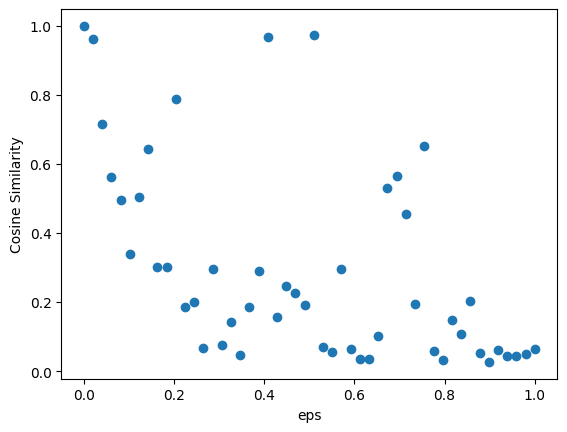

In [45]:
plt.scatter(res["eps"], res["cos"])
plt.xlabel("eps")
plt.ylabel("Cosine Similarity")

Text(0, 0.5, 'Cosine Similarity')

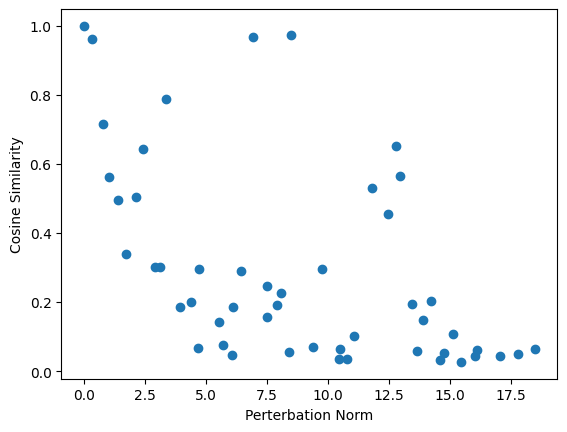

In [46]:
plt.scatter(res["perterbation_norm"], res["cos"])
plt.xlabel("Perterbation Norm")
plt.ylabel("Cosine Similarity")

In [56]:
np.linalg.norm(alpha1)

np.float64(112.7542625423627)

In [ ]:
class ModifiedGaussianKernel2:
    def __init__(self, bandwidth, c):
        self.bandwidth = bandwidth
        
    def __call__(self, x1, x2):
        x1_dim = len(x1.shape)
        x2_dim = len(x2.shape)

        if x1_dim != x2_dim:
            raise Exception("GaussianKernel: x1 and x2 should have the same number of dimensions")

        if x1_dim == 1:
            return np.exp(-(x2[np.newaxis, :]- x1[:, np.newaxis])**2/(2*self.bandwidth**2))*(1/self.bandwidth)*c*np.exp(-)
        elif x1_dim == 2:
            return np.exp(-np.linalg.norm(x2[np.newaxis, :, :]- x1[:, np.newaxis, :], axis=2)**2/(2*self.bandwidth**2))*(1/self.bandwidth)
        else:
            return np.exp(-np.linalg.norm(x2[np.newaxis, :, :]- x1[:, np.newaxis, :], axis=(2, 3))**2/(2*self.bandwidth**2))*(1/self.bandwidth)

        raise Exception("Number of dimensions of the data is too big!")


In [ ]:
class ModifiedKRRWrapper2(BaseEstimator):
    def __init__(self, bandwidth, reg):
        self.model = KernelRidgeRegression(
            kernels=[ModifiedGaussianKernel(bandwidth=bandwidth)],
            reg = reg
        )

    def fit(self, X, y):
        self.model.fit(X, y)

    def predict(self, X):
        return self.model.predict(X)

In [59]:
f = lambda x: np.exp(-x**2)

In [60]:
paramsearch = GridSearch(
    ModifiedKRRWrapper,
    param_grid=dict(
        bandwidth=np.linspace(1, 5, 50),
        reg = np.linspace(1e-9, 1e-2, 20)
    )
)

In [61]:
paramsearch.fit(x, f(x))

b1, r1 = paramsearch.best_params.values()

In [62]:
res_bw_exp = defaultdict(list)
for eps in tqdm.tqdm(np.linspace(0, 1, 50)):
    res_temp = defaultdict(list)

    for i in range(100):
        y1 = f(x) + np.random.normal(0, 1, len(x))
        model1 = ModifiedKRRWrapper(b1, r1)
        model1.fit(x, y1)

        kernel1 = model1.model.kernels[0]
        alpha1 = model1.model.alpha

        b2 = b1 + eps - 0.5

        paramsearch = GridSearch(
            ModifiedKRRWrapper,
            param_grid=dict(
                bandwidth=[b2],
                reg = np.linspace(1e-9, 1e-2, 20)
            )
        )

        # paramsearch.fit(x, y1)
        # r2 = paramsearch.best_params["reg"]
        r2 = r1

        model2 = ModifiedKRRWrapper(b2, r2)
        model2.fit(x, y1)

        kernel2 = model2.model.kernels[0]
        alpha2 = model2.model.alpha


        ip1 = (alpha1.T@kernel1(x, x)@alpha1)[0][0]
        ip2 = (alpha2.T@kernel2(x, x)@alpha2)[0][0]

        c = b1/b2
        ip12 = (alpha2.T@kernel1(c*x, x)@alpha1)[0,0]*c

        res_temp["cos"] = ip12/np.sqrt(ip1*ip2)
        

    for k, v in res_temp.items():
        res_bw_exp[k].append(np.mean(v))

    res_bw_exp["eps"].append(eps)

100%|██████████| 50/50 [00:41<00:00,  1.20it/s]


Text(0, 0.5, 'Cosine Similarity')

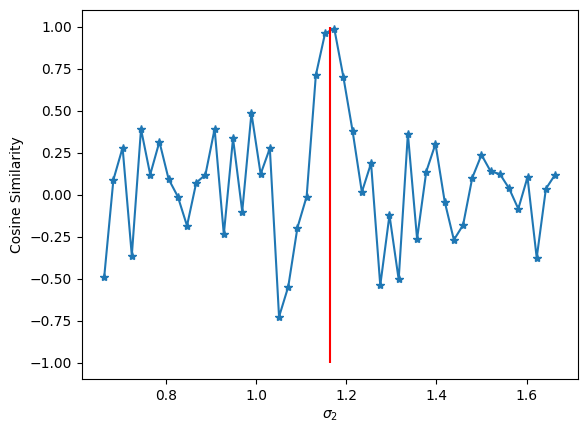

In [68]:
plt.plot(np.array(res_bw_exp["eps"]) - 0.5 + b1, res_bw_exp["cos"], "-*")
plt.vlines(b1, -1, 1, "r")
plt.xlabel("$\\sigma_2$")
plt.ylabel("Cosine Similarity")

In [ ]:
res_bw = defaultdict(list)
for eps in tqdm.tqdm(np.linspace(0, 1, 50)):
    res_temp = defaultdict(list)

    for i in range(100):
        y1 = f(x) + np.random.normal(0, 1, len(x))
        model1 = ModifiedKRRWrapper(b1, r1)
        model1.fit(x, y1)

        kernel1 = model1.model.kernels[0]
        alpha1 = model1.model.alpha

        b2 = b1 + eps - 0.5

        paramsearch = GridSearch(
            ModifiedKRRWrapper,
            param_grid=dict(
                bandwidth=[b2],
                reg = np.linspace(1e-9, 1e-2, 20)
            )
        )

        # paramsearch.fit(x, y1)
        # r2 = paramsearch.best_params["reg"]
        r2 = r1

        model2 = ModifiedKRRWrapper(b2, r2)
        model2.fit(x, y1)

        kernel2 = model2.model.kernels[0]
        alpha2 = model2.model.alpha


        ip1 = (alpha1.T@kernel1(x, x)@alpha1)[0][0]
        ip2 = (alpha2.T@kernel2(x, x)@alpha2)[0][0]

        c = b1/b2
        ip12 = (alpha2.T@kernel1(c*x, x)@alpha1)[0,0]*c

        res_temp["cos"] = ip12/np.sqrt(ip1*ip2)
        

    for k, v in res_temp.items():
        res_bw[k].append(np.mean(v))

    res_bw["eps"].append(eps)